In [25]:
!pip install networkx


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


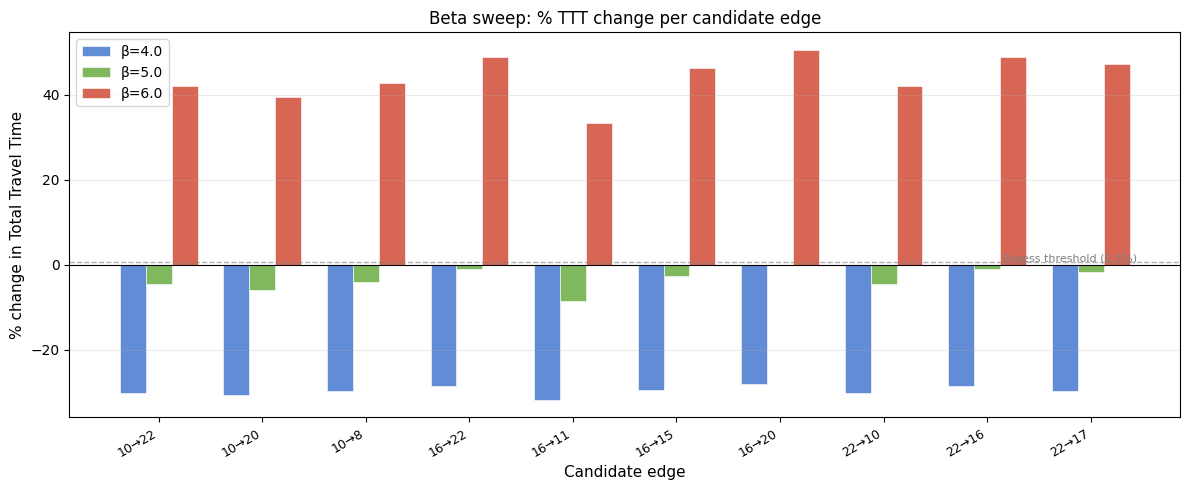

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('outputs/beta_sweep_results.csv')

betas = sorted(df['beta'].unique())

# Combine from+to into a readable label like "16→20"
df['edge'] = df['from'].astype(str) + '→' + df['to'].astype(str)
edges = df[df['beta'] == betas[0]]['edge'].tolist()

x = np.arange(len(edges))
width = 0.25
colors = ['#4878CF', '#6AAC41', '#D04B36']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (beta, color) in enumerate(zip(betas, colors)):
    vals = df[df['beta'] == beta]['pct_change'].values
    ax.bar(x + i*width, vals, width, label=f'β={beta}',
           color=color, alpha=0.85, edgecolor='white', lw=0.5)

ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.5, color='gray', lw=1, ls='--', alpha=0.6)
ax.text(len(edges) - 0.3, 0.7, 'Braess threshold (0.5%)',
        fontsize=8, color='gray', ha='right')

# Centre the tick group under all 3 bars for each edge
ax.set_xticks(x + width)
ax.set_xticklabels(edges, rotation=30, ha='right', fontsize=9)
ax.set_xlabel('Candidate edge', fontsize=11)
ax.set_ylabel('% change in Total Travel Time', fontsize=11)
ax.set_title('Beta sweep: % TTT change per candidate edge', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

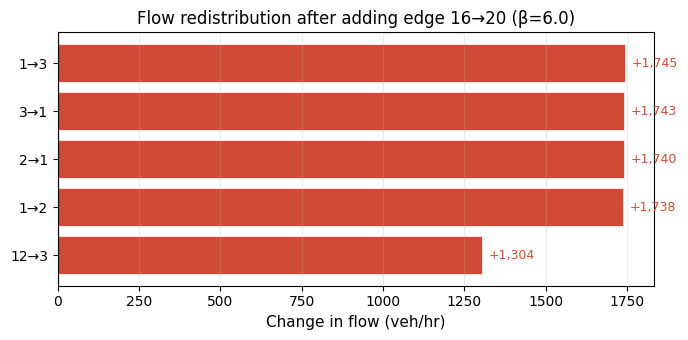

In [ ]:
import matplotlib.pyplot as plt

links   = ['1→3', '3→1', '2→1', '1→2', '12→3']
delta   = [1744.8, 1742.6, 1740.5, 1738.3, 1304.0]
colors  = ['#D04B36' if d > 0 else '#4878CF' for d in delta]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(links, delta, color=colors, edgecolor='white', lw=0.5)

for bar, val in zip(bars, delta):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'+{val:,.0f}', va='center', fontsize=9, color='#D04B36')

ax.set_xlabel('Change in flow (veh/hr)', fontsize=11)
ax.set_title('Flow redistribution after adding edge 16→20 (β=6.0)', fontsize=12)
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

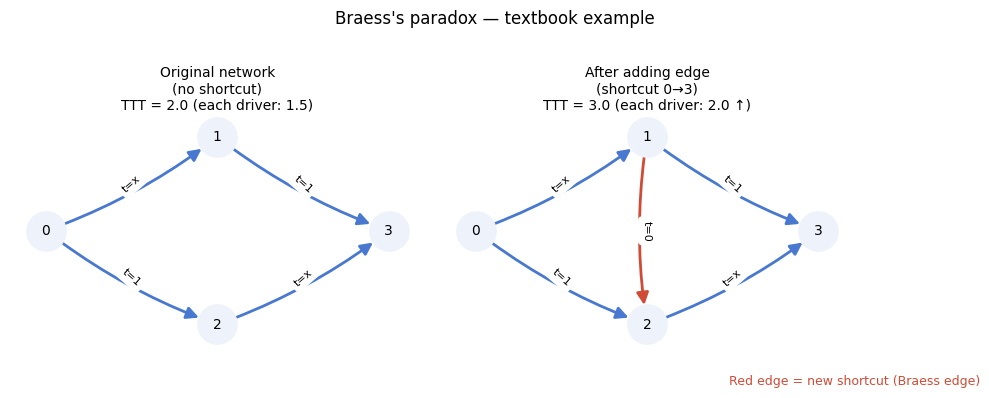

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, add_edge, title, ttt in zip(
    axes,
    [False, True],
    ['Original network\n(no shortcut)', 'After adding edge\n(shortcut 0→3)'],
    ['TTT = 2.0 (each driver: 1.5)', 'TTT = 3.0 (each driver: 2.0 ↑)']
):
    G = nx.DiGraph()
    pos = {0: (0,0.5), 1: (1,1), 2: (1,0), 3: (2,0.5)}
    edges = [(0,1,'t=x'), (1,3,'t=1'), (0,2,'t=1'), (2,3,'t=x')]
    for u, v, l in edges:
        G.add_edge(u, v, label=l)
    if add_edge:
        G.add_edge(1, 2, label='t=0')

    edge_colors = []
    for u, v in G.edges():
        if (u, v) == (1, 2):
            edge_colors.append('#D04B36')
        else:
            edge_colors.append('#4878CF')

    nx.draw_networkx(G, pos=pos, ax=ax,
                     node_color='#EEF2FB', node_size=800,
                     edge_color=edge_colors, arrows=True,
                     arrowsize=18, font_size=10, width=2,
                     connectionstyle='arc3,rad=0.08')

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 ax=ax, font_size=8)
    ax.set_title(f'{title}\n{ttt}', fontsize=10)
    ax.axis('off')

axes[1].text(1.0, -0.18, 'Red edge = new shortcut (Braess edge)',
             ha='center', fontsize=9, color='#D04B36',
             transform=axes[1].transAxes)

plt.suptitle("Braess's paradox — textbook example", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

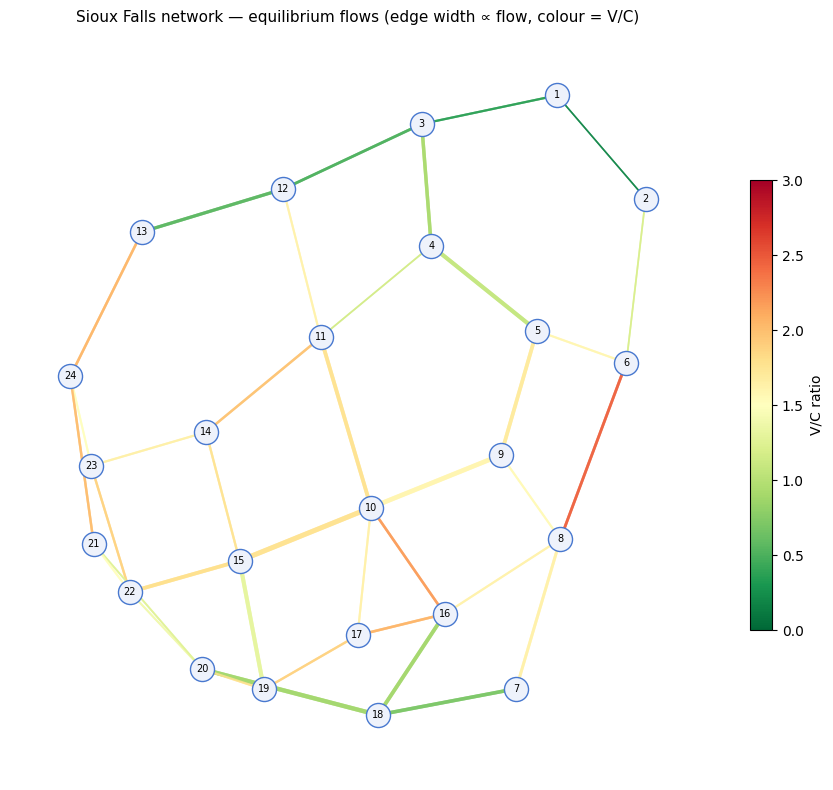

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

net = pd.read_csv('outputs/initial_equilibrium_output.csv')  # adjust col names
# Expected cols: from_node, to_node, flow, capacity, free_flow_time

G = nx.DiGraph()
for _, row in net.iterrows():
    G.add_edge(int(row['init_node']), int(row['term_node']),
               flow=row['flow'], vc=row['flow']/row['capacity'])

pos = nx.spring_layout(G, seed=42)  # or load real Sioux Falls coords

vc_vals  = [G[u][v]['vc']   for u,v in G.edges()]
flows    = [G[u][v]['flow'] for u,v in G.edges()]
max_flow = max(flows)

edge_colors = [cm.RdYlGn_r(min(vc/3, 1)) for vc in vc_vals]
edge_widths = [0.5 + 3 * f/max_flow for f in flows]

fig, ax = plt.subplots(figsize=(9, 8))
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300,
                       node_color='#EEF2FB', edgecolors='#4878CF', linewidths=1)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
nx.draw_networkx_edges(G, pos, ax=ax,
                       edge_color=edge_colors, width=edge_widths,
                       arrows=False, alpha=0.8)

# Highlight the Braess edge
if G.has_edge(16, 20):
    nx.draw_networkx_edges(G, pos, edgelist=[(16,20)], ax=ax,
                           edge_color='red', width=3, arrows=True,
                           arrowsize=20, style='dashed')

sm = plt.cm.ScalarMappable(cmap=cm.RdYlGn_r, norm=plt.Normalize(0, 3))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='V/C ratio', shrink=0.6)

ax.set_title('Sioux Falls network — equilibrium flows (edge width ∝ flow, colour = V/C)',
             fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()